In [11]:
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

df = pd.read_csv("car_evaluation.csv")
df.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   object
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB
None


In [12]:
print(df[df.duplicated()])
print(df.duplicated().sum())

Empty DataFrame
Columns: [buying, maint, doors, persons, lug_boot, safety, class]
Index: []
0


In [13]:
print(df["buying"].unique())
print(df["maint"].unique())
print(df["doors"].unique())
print(df["persons"].unique())
print(df["lug_boot"].unique())
print(df["safety"].unique())
print(df["class"].unique())

['vhigh' 'high' 'med' 'low']
['vhigh' 'high' 'med' 'low']
['2' '3' '4' '5more']
['2' '4' 'more']
['small' 'med' 'big']
['med' 'high' 'low']
['unacc' 'acc' 'vgood' 'good']


In [14]:
target = 'class'
y = df[target]
X = df.drop([target], axis = 1)

y = LabelEncoder().fit_transform(y)
        
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [27]:
encoder = OneHotEncoder(sparse_output = False, handle_unknown = 'ignore')
X_train_encoded = encoder.fit_transform(X_train)

X_test_encoded = encoder.transform(X_test)

In [42]:
num_classes = 4
model = keras.Sequential([
            layers.Input(shape = (X_train_encoded.shape[1],)),
            layers.Dense(16, activation = "relu"),
            layers.Dense(8, activation = "relu"),
            layers.Dense(num_classes, activation = "softmax")
        ])
model.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.001), loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])
history = model.fit(X_train_encoded, y_train, epochs = 20, batch_size = 16, validation_data = (X_test_encoded, y_test), verbose = 1)
loss, accuracy = model.evaluate(X_test_encoded, y_test)
print(f"Loss: {loss}\nAccuracy: {accuracy}")

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6474 - loss: 1.0544 - val_accuracy: 0.6850 - val_loss: 0.8953
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7038 - loss: 0.7547 - val_accuracy: 0.6850 - val_loss: 0.7693
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7125 - loss: 0.6365 - val_accuracy: 0.7110 - val_loss: 0.6323
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7647 - loss: 0.5214 - val_accuracy: 0.7977 - val_loss: 0.5085
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8313 - loss: 0.4302 - val_accuracy: 0.8179 - val_loss: 0.4230
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8595 - loss: 0.3643 - val_accuracy: 0.8497 - val_loss: 0.3613
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8747 - loss: 0.3160 - val_accuracy: 0.8873 - val_loss: 0.3108
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8892 - loss: 0.2809 - val_accuracy: 0.8960 - val_loss:

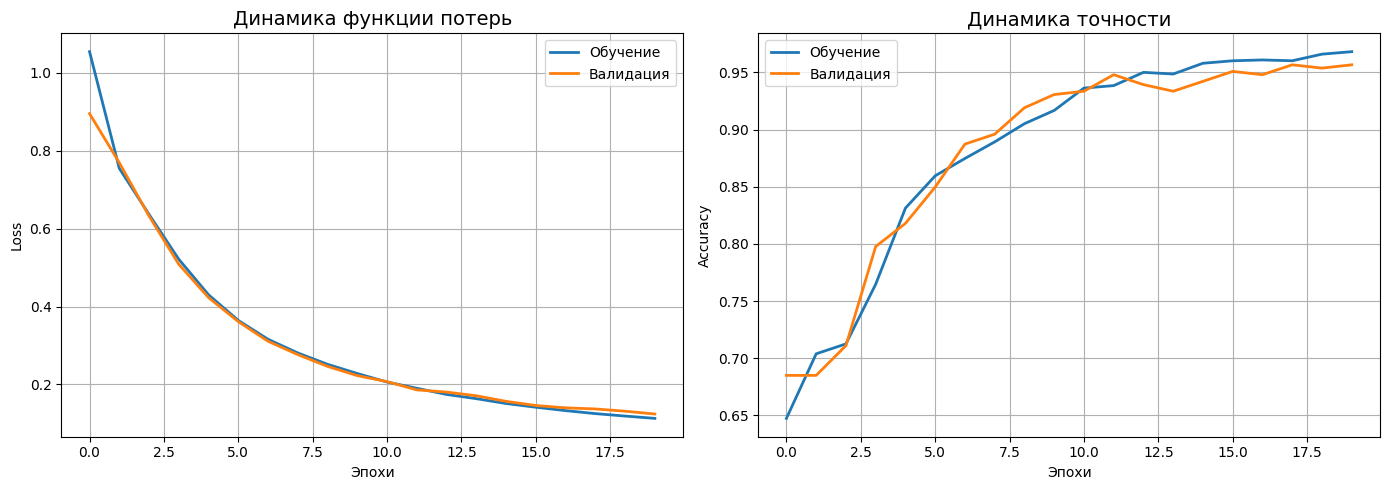

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))
ax1.plot(history.history['loss'], label = 'Обучение', linewidth = 2)
ax1.plot(history.history['val_loss'], label = 'Валидация', linewidth = 2)
ax1.set_title('Динамика функции потерь', fontsize = 14)
ax1.set_xlabel('Эпохи')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['accuracy'], label = 'Обучение', linewidth = 2)
ax2.plot(history.history['val_accuracy'], label = 'Валидация', linewidth = 2)
ax2.set_title('Динамика точности', fontsize = 14)
ax2.set_xlabel('Эпохи')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()